# Alveolar ROI reconstruction and readable plane addresses

This notebook extends v27 without changing the whole-lung reference geometry. It reconstructs a separate local ROI from public 1.1 µm projection data and records its acquisition frame. It is not a registration to m07, D14 or D30, nor an individual-alveolus atlas. Geometry from thresholded reconstructed intensity is exploratory and must be checked against grayscale slices.

Source: Lovric et al., [PLOS ONE 2017](https://doi.org/10.1371/journal.pone.0183979); [Harvard Dataverse](https://doi.org/10.7910/DVN/XO8FQY). The 10 cmH2O scan is used. The dataset contains 30 dark, 100 pre-flat, 901 projections and 100 post-flat images according to its README. The authors used phase retrieval and gridrec plus specialized septum segmentation; our restricted ROI workflow is explicitly documented below and is not a reproduction of their entire pipeline.

All implementation, UI changes and validation are kept here in English. Source data and prior HTML snapshots are ignored local inputs; generated QA and provenance are versioned. Body/lung frame and alveolar acquisition frame must remain separate.


## Reuse and local layout

- Raw split archives, source metadata and derived volume caches: `data/alveolar_roi/`. File IDs 3042405 and 3042406 are downloadable from `https://dataverse.harvard.edu/api/access/datafile/<ID>`. The notebook verifies repository MD5 checksums before reading. Manifest endpoint: `https://dataverse.harvard.edu/api/datasets/:persistentId/?persistentId=doi:10.7910/DVN/XO8FQY`.
- Prior HTML inputs: `viewer/archive/`; current output: `lung_viewer/mouse_lung_v28.html`. No input/output path depends on `random`.
- Use the `xenium_rebuild` environment with NumPy, SciPy, scikit-image, tifffile, matplotlib, nbformat/IPython, and Node.js. Source archives are ~4.3 GB; derived caches are local. HTML uses the existing Three.js CDN and embeds its ROI volume.
- Cells run in order. Set a new ROI/output filename when changing reconstruction parameters; the fixed volume cache filename currently describes this specific ROI. Do not reuse it after changing filters/center/binning. Original projection bytes are preserved.
- The 2.2 µm surface is an exploratory thresholded interface. Independent labeling of individual alveoli, high-resolution phase retrieval, vessel discrimination and registration are outside this output's claims.

In [1]:
from pathlib import Path
import json, hashlib, io, zipfile, re, os, base64, gzip, subprocess, time
import numpy as np
import tifffile
from scipy import ndimage as ndi
from skimage.transform import iradon
from skimage.registration import phase_cross_correlation
from skimage.filters import threshold_otsu
from skimage.measure import marching_cubes
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'viewer').exists())
DATA=ROOT/'data/alveolar_roi'
OUT=ROOT/'qa/alveolar_roi';OUT.mkdir(exist_ok=True,parents=True)
manifest=json.loads((DATA/'alveolar_manifest.json').read_text())['data']['latestVersion']
parts=[DATA/'1.1micron_10cmH2O_rawdata.zip.aa',DATA/'1.1micron_10cmH2O_rawdata.zip.ab']
checks=[]
for p in parts:
    entry=next(f['dataFile'] for f in manifest['files'] if f['dataFile']['filename']==p.name)
    assert p.stat().st_size==entry['filesize'], 'Download incomplete: '+p.name
    h=hashlib.md5()
    with p.open('rb') as f:
        for block in iter(lambda:f.read(8*1024**2),b''):h.update(block)
    assert h.hexdigest()==entry['checksum']['value'], 'Source checksum mismatch'
    checks.append({'file':p.name,'md5':h.hexdigest(),'bytes':p.stat().st_size})
# Seekable virtual concatenation avoids an extra 4 GB copy.
class JoinedParts(io.RawIOBase):
    def __init__(self,paths):
        self.handles=[p.open('rb') for p in paths];self.ends=np.cumsum([p.stat().st_size for p in paths]);self.pos=0
    def readable(self):return True
    def seekable(self):return True
    def tell(self):return self.pos
    def seek(self,offset,whence=0):
        self.pos=int(offset if whence==0 else self.pos+offset if whence==1 else self.ends[-1]+offset);return self.pos
    def read(self,n=-1):
        if n<0:n=int(self.ends[-1]-self.pos)
        chunks=[]
        while n>0 and self.pos<self.ends[-1]:
            k=int(np.searchsorted(self.ends,self.pos,side='right'));start=0 if k==0 else self.ends[k-1]
            self.handles[k].seek(self.pos-int(start));size=min(n,int(self.ends[k]-self.pos));b=self.handles[k].read(size)
            if not b:break
            chunks.append(b);self.pos+=len(b);n-=len(b)
        return b''.join(chunks)
archive=zipfile.ZipFile(JoinedParts(parts))
files=sorted(f for f in archive.namelist() if f.lower().endswith(('.tif','.tiff')))
print('TIFF files:',len(files),'first:',files[:3],'last:',files[-3:])
print('Other files:',[f for f in archive.namelist() if f not in files][:20])
(OUT/'source_checksums.json').write_text(json.dumps(checks,indent=2))

TIFF files: 1131 first: ['tif/mouseE020001.tif', 'tif/mouseE020002.tif', 'tif/mouseE020003.tif'] last: ['tif/mouseE021129.tif', 'tif/mouseE021130.tif', 'tif/mouseE021131.tif']
Other files: ['tif/', 'tif/TARCHIVE/', 'tif/mouseE02.log', 'tif/mouseE0200_.xml', 'tif/reco.set']


## Projection preparation and pilot reconstruction

The archive log confirms 0–180 degrees in 0.2-degree steps, detector 2016², 1.10 µm pixels, and saved rotation center 1008.13. The log's beam-energy field is evidently inconsistent with the published 21 keV; no phase-retrieval energy is inferred from that field. We reconstruct **propagation-contrast FBP**, not the paper's Paganin/gridrec workflow. Thin bright/dark edge fringes therefore remain a material limitation.

For an interactive pilot, detector pixels are averaged 2×2 (2.2 µm effective sampling; not 1.1 µm resolution). Detector rows 900:1092 define a 211.2 µm axial ROI. Darks and pre/post flats are averaged; flat fields are interpolated across acquisition time; clipped positive transmission is log-transformed. A Hann-windowed ramp is used for FBP. The 180-degree endpoint is dropped to avoid double weighting. Cache keys include all parameters; cached data are derived, not deposited raw data.

Projection array: (900, 96, 1008) clipped transmissions: 0 center shift: 0.18500000000000227


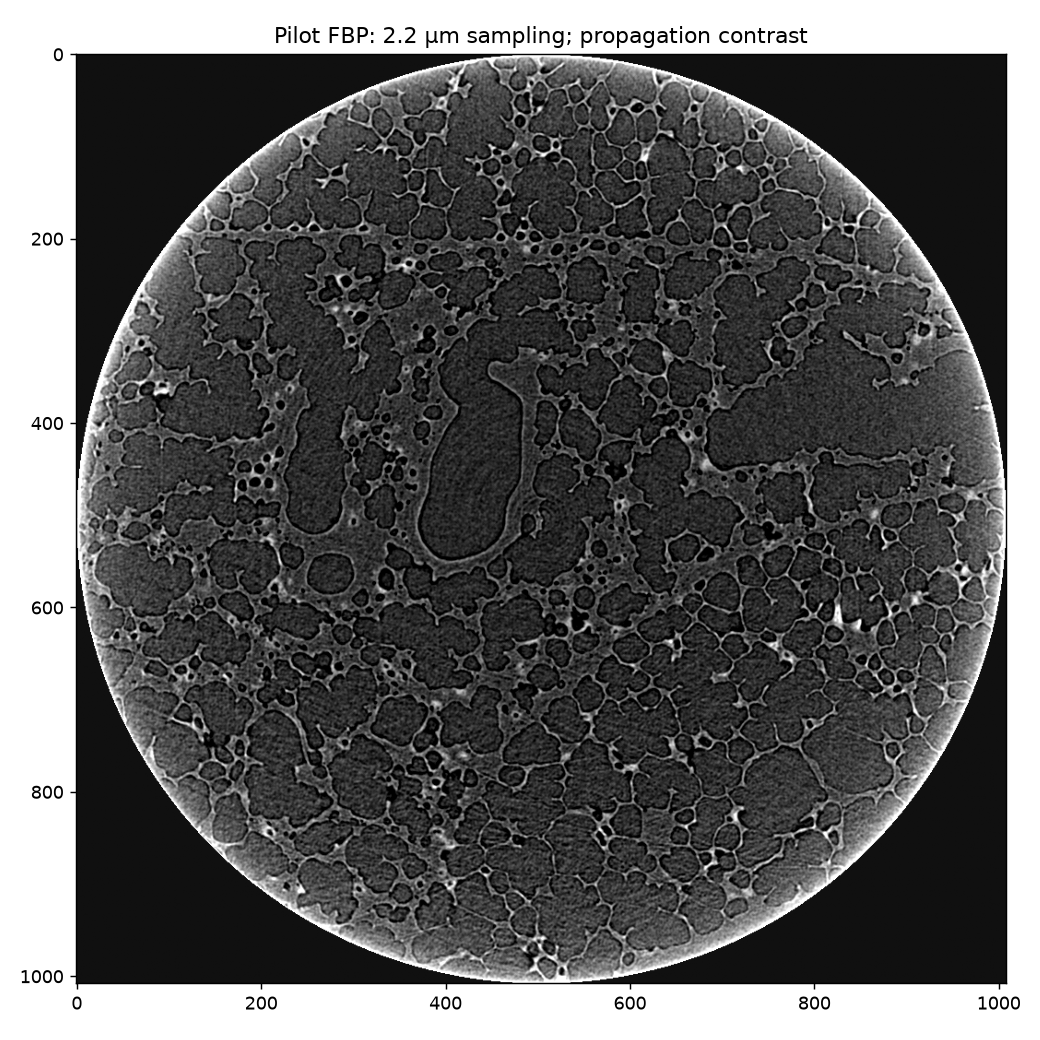

In [2]:
PARAM={'rows':[900,1092],'bin':2,'source_pixel_um':1.1,'center_detector_px':1008.13,'projection_count':900,'filter':'hann','flat':'linear_pre_post','reconstruction':'propagation_contrast_FBP'}
key=hashlib.sha256(json.dumps(PARAM,sort_keys=True).encode()).hexdigest()[:12]
cache=DATA/f'projection_band_{key}.npz'
log=archive.read('tif/mouseE02.log').decode()
assert 'Angular step [deg]           : 0.200' in log
(OUT/'acquisition_log.txt').write_text(log)
def read_band(index):
    im=tifffile.imread(io.BytesIO(archive.read(files[index])))
    assert im.shape==(2016,2016)
    band=im[900:1092].astype(np.float32)
    return band.reshape(96,2,1008,2).mean(axis=(1,3))
if not cache.exists():
    dark=np.mean([read_band(i) for i in range(30)],axis=0)
    flat0=np.mean([read_band(i) for i in range(30,130)],axis=0)
    flat1=np.mean([read_band(i) for i in range(1031,1131)],axis=0)
    projections=np.empty((900,96,1008),np.float32)
    clipped=0
    for j in range(900):
        f=j/900;den=np.maximum((1-f)*flat0+f*flat1-dark,1)
        trans=(read_band(130+j)-dark)/den
        clipped+=int((trans<1e-4).sum())
        projections[j]=-np.log(np.clip(trans,1e-4,4))
    np.savez_compressed(cache,projections=projections,clipped=clipped)
else:
    with np.load(cache) as c:projections=c['projections'];clipped=int(c['clipped'])
# Pixel bin centers are source positions 0.5,2.5,... . Convert saved center to binned index.
center=(PARAM['center_detector_px']-.5)/2
shift=1008//2-center
projections=ndi.shift(projections,(0,0,shift),order=1,mode='nearest',prefilter=False)
theta=np.arange(900)*.2
pilot=iradon(projections[:,48,:].T,theta=theta,filter_name='hann',circle=True,preserve_range=True)
np.save(DATA/'pilot_reconstruction.npy',pilot)
fig,ax=plt.subplots(figsize=(8,8));lo,hi=np.percentile(pilot,[5,99]);ax.imshow(pilot,cmap='gray',vmin=lo,vmax=hi);ax.set_title('Pilot FBP: 2.2 µm sampling; propagation contrast');fig.tight_layout();fig.savefig(OUT/'pilot_reconstruction.png',dpi=130);plt.close(fig)
display(Image(filename=str(OUT/'pilot_reconstruction.png')))
print('Projection array:',projections.shape,'clipped transmissions:',clipped,'center shift:',shift)

## Local FBP volume and exploratory tissue surface

Select a 160×160×96 voxel region at pilot image rows 610:770, columns 620:780 (352×352×211.2 µm). These are reconstruction indices, not anatomical axes. The ROI is chosen visually within parenchyma, avoiding the large central lumen. Reconstruct all 96 rows using the same Hann-filtered parallel-beam equations as scikit-image `iradon`, but evaluate only the desired XY coordinates. Validate the central ROI against the full pilot slice.

Subtract a slowly varying Gaussian background and apply mild Gaussian denoising, then Otsu thresholding to produce an exploratory bright-tissue mask. No alveolus counting or individually closed sacs are inferred; propagation fringes and missed thin septa remain possible. Compare the chosen threshold to ±15% perturbations. Marching cubes extracts the air/tissue interface without padding the ROI, so cut faces are not fabricated as membranes. The HTML retains grayscale sections with an optional mask overlay.

{
  "doi": "10.7910/DVN/XO8FQY",
  "scan": "mouseE02",
  "pressure_cmH2O": 10,
  "source_pixel_um": 1.1,
  "effective_voxel_um": 2.2,
  "frame": "acquisition-ROI-XYZ-not-anatomical",
  "roi_original_detector_rows": [
    900,
    1092
  ],
  "roi_reconstruction_y": [
    610,
    770
  ],
  "roi_reconstruction_x": [
    620,
    780
  ],
  "shape_zyx": [
    96,
    160,
    160
  ],
  "reconstruction": {
    "rows": [
      900,
      1092
    ],
    "bin": 2,
    "source_pixel_um": 1.1,
    "center_detector_px": 1008.13,
    "projection_count": 900,
    "filter": "hann",
    "flat": "linear_pre_post",
    "reconstruction": "propagation_contrast_FBP"
  },
  "fbp_pilot_relative_error": 0.0,
  "threshold": 0.000513026025146246,
  "tissue_fraction": 0.13954630533854168,
  "mesh_vertices": 433334,
  "mesh_faces": 858962,
  "interpretation": "exploratory tissue interface; not individually segmented alveoli; no m07 registration"
}


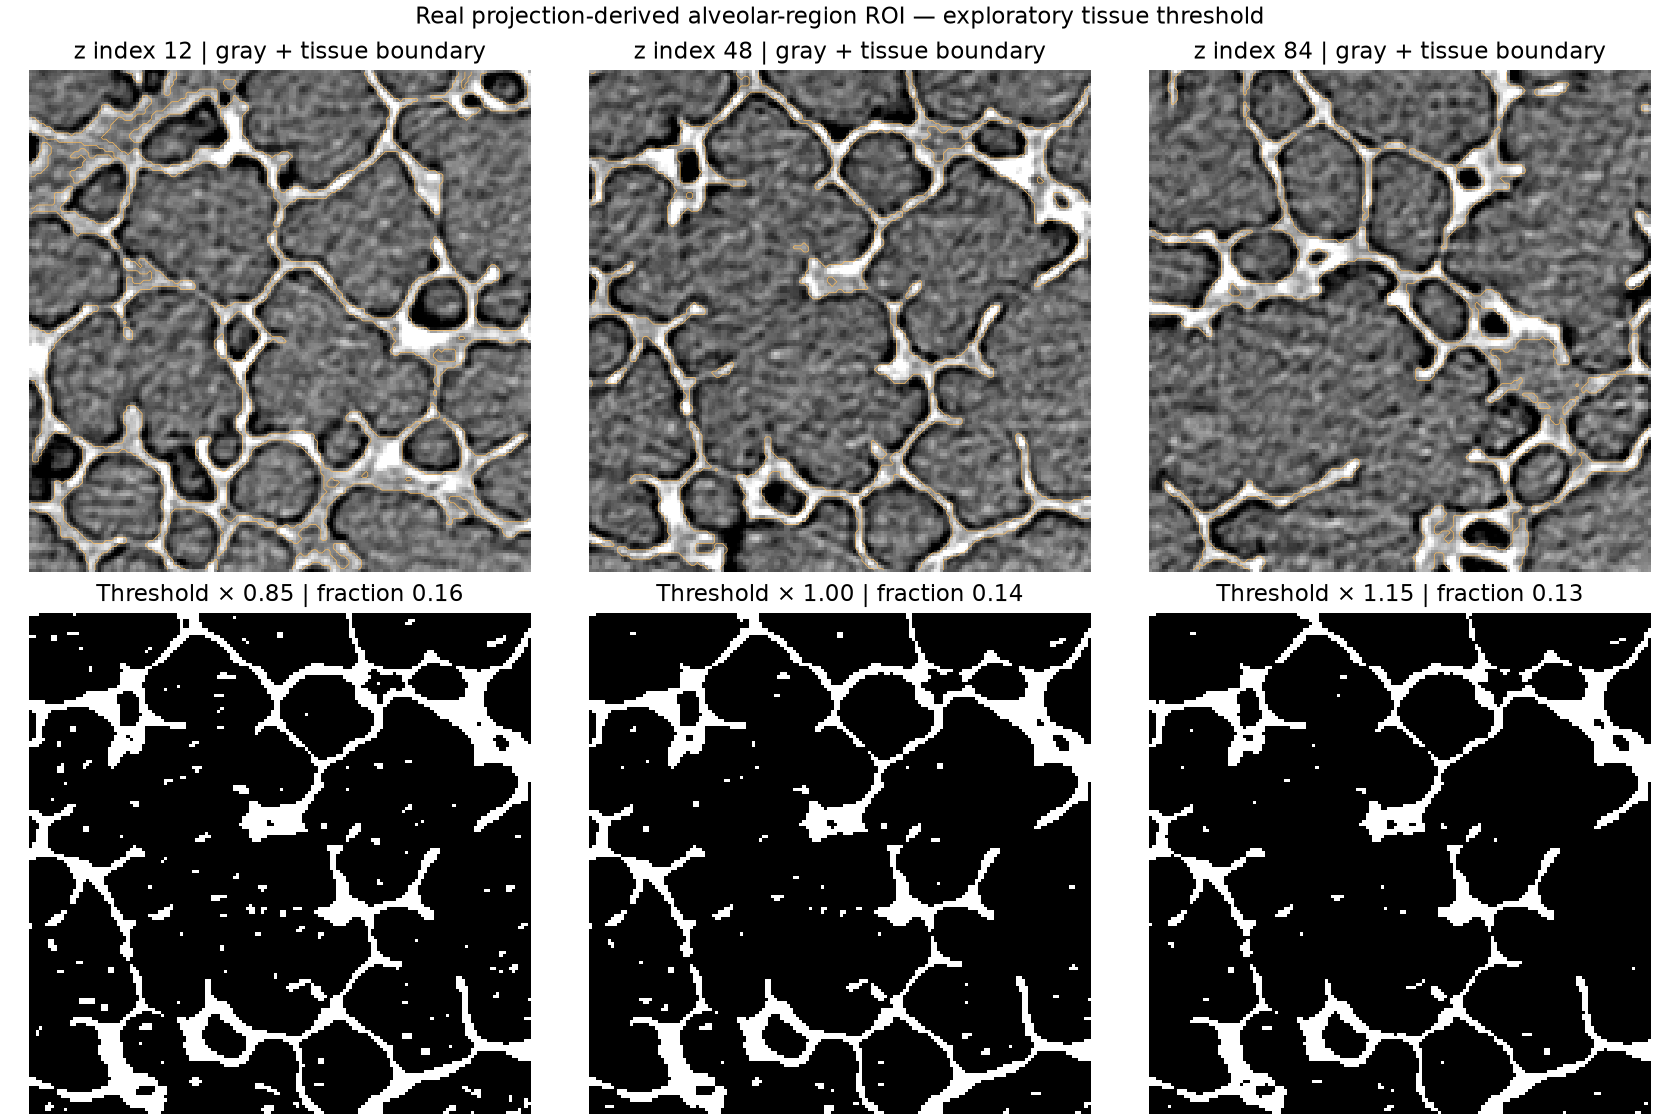

In [3]:
from skimage.transform.radon_transform import _get_fourier_filter, _sinogram_circle_to_square
from scipy.fft import fft, ifft
ROI_Y=(610,770);ROI_X=(620,780);VOXEL_UM=2.2
volume_path=DATA/'roi_fbp_y610_770_x620_780_z900_1092.npy'
def reconstruct_roi(sino):
    sq=_sinogram_circle_to_square(sino);length=sq.shape[0]
    padded=max(64,int(2**np.ceil(np.log2(2*length))))
    filtered=ifft(fft(np.pad(sq,((0,padded-length),(0,0))),axis=0)*_get_fourier_filter(padded,'hann'),axis=0).real[:length]
    rows,cols=np.mgrid[ROI_Y[0]:ROI_Y[1],ROI_X[0]:ROI_X[1]];rows=rows-504;cols=cols-504
    result=np.zeros(rows.shape,np.float32);x=np.arange(length)-length//2
    for col,a in zip(filtered.T,np.deg2rad(theta)):
        result+=np.interp(cols*np.cos(a)-rows*np.sin(a),x,col,left=0,right=0)
    return result*np.pi/(2*len(theta))
if not volume_path.exists():
    volume=np.stack([reconstruct_roi(projections[:,z,:].T) for z in range(96)])
    np.save(volume_path,volume)
else:volume=np.load(volume_path)
expected=pilot[ROI_Y[0]:ROI_Y[1],ROI_X[0]:ROI_X[1]]
relative_error=float(np.max(np.abs(volume[48]-expected))/max(np.max(abs(expected)),1e-9))
assert relative_error<1e-4,relative_error
smoothed=ndi.gaussian_filter(volume,.65)
corrected=smoothed-ndi.gaussian_filter(smoothed,12)
threshold=float(threshold_otsu(corrected))
mask=corrected>threshold
lab,k=ndi.label(mask);counts=np.bincount(lab.ravel());keep=counts>=48;keep[0]=False;mask=keep[lab]
verts,faces,normals,values=marching_cubes(ndi.gaussian_filter(mask.astype(np.float32),.55),.5,spacing=(VOXEL_UM,)*3,step_size=1,allow_degenerate=False)
# Marching cubes yields z,y,x; viewer coordinates are x,y,z acquisition indices.
verts=verts[:,[2,1,0]];verts-=np.array([159,159,95])*VOXEL_UM/2
np.savez_compressed(DATA/'alveolar_roi_volume.npz',grayscale=volume,corrected=corrected,mask=mask,voxel_um=VOXEL_UM)
np.savez_compressed(DATA/'alveolar_roi_mesh.npz',vertices=verts,faces=faces)
fig,axs=plt.subplots(2,3,figsize=(12,8),layout='constrained')
for ax,z in zip(axs[0],[12,48,84]):
    im=volume[z];a,b=np.percentile(im,[2,98]);ax.imshow(im,cmap='gray',vmin=a,vmax=b);ax.contour(mask[z],levels=[.5],colors='#ffbd59',linewidths=.35);ax.set_title(f'z index {z} | gray + tissue boundary');ax.axis('off')
for ax,factor in zip(axs[1],[.85,1,1.15]):
    trial=corrected[48]>threshold*factor;ax.imshow(trial,cmap='gray');ax.set_title(f'Threshold × {factor:.2f} | fraction {trial.mean():.2f}');ax.axis('off')
fig.suptitle('Real projection-derived alveolar-region ROI — exploratory tissue threshold')
fig.savefig(OUT/'alveolar_roi_qc.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'alveolar_roi_qc.png')))
provenance={'doi':'10.7910/DVN/XO8FQY','scan':'mouseE02','pressure_cmH2O':10,'source_pixel_um':1.1,'effective_voxel_um':2.2,'frame':'acquisition-ROI-XYZ-not-anatomical','roi_original_detector_rows':[900,1092],'roi_reconstruction_y':list(ROI_Y),'roi_reconstruction_x':list(ROI_X),'shape_zyx':list(volume.shape),'reconstruction':PARAM,'fbp_pilot_relative_error':relative_error,'threshold':threshold,'tissue_fraction':float(mask.mean()),'mesh_vertices':len(verts),'mesh_faces':len(faces),'interpretation':'exploratory tissue interface; not individually segmented alveoli; no m07 registration'}
(OUT/'alveolar_provenance.json').write_text(json.dumps(provenance,indent=2))
print(json.dumps(provenance,indent=2))

## Readable plane addresses and UI

The new address is `M07-RVCR1@<12-digit geometry reference>;az=<degrees>;el=<degrees>;d=<mm>`. It names the model and coordinate convention, rather than exposing encoded JSON. The short geometry reference resolves to the full SHA-256 embedded in this viewer; it is intended to reject accidental mismatches, not to provide cryptographic authentication. Azimuth rotates the normal from +right toward +ventral; elevation rotates toward +cranial; d is its signed offset from the fixed lung-model origin. Legacy LP1 IDs remain accepted. Six decimal places are serialization precision, not biological accuracy.

Controls use collapsible sections, dark text inputs and short readouts. The requested middle/accessory and day buttons are removed. Prior day hypotheses remain in notebook 16 outputs; they are not presented as anatomy in the default UI. V28 is created in this repository; prior HTML versions live in `lung_viewer/archive`.

In [4]:
# Build v28 from the preserved v27, with portable readable addresses and a compact UI.
SOURCE=ROOT/'viewer/archive/mouse_lung_3d_blender_detail_v27_anatomy_reference.html'
DEST=ROOT/'viewer/mouse_lung_v28.html'
viewer=SOURCE.read_text()
mesh_payload=re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S)[1]
viewer=viewer.replace('Mouse lung explorer · v27','Mouse lung explorer · v28').replace('v27 · C57BL/6 m07','v28 · C57BL/6 m07')
viewer=viewer.replace('function encodePlane(a,b,d){','function encodeLegacyPlane(a,b,d){',1).replace('function decodePlane(text){','function decodeLegacyPlane(text){',1)
UI_JS='// Human-readable plane address; LP1 remains accepted for backward compatibility.\nfunction encodePlane(a,b,d){return `M07-RVCR1@${PLANE_MODEL.slice(0,12)};az=${a.toFixed(6)}deg;el=${b.toFixed(6)}deg;d=${d.toFixed(6)}mm`;}\nfunction decodePlane(text){\n let id=text.trim();if(id.includes(\'#\'))id=decodeURIComponent(id.slice(id.indexOf(\'#\')+1));if(id.startsWith(\'plane=\'))id=id.slice(6);id=id.replace(/\\s+/g,\'\');\n if(id.startsWith(\'LP1.\'))return decodeLegacyPlane(id);\n const m=/^M07-RVCR1@([a-f0-9]{12});az=([-+\\d.eE]+)deg;el=([-+\\d.eE]+)deg;d=([-+\\d.eE]+)mm$/.exec(id);\n if(!m||m[1]!==PLANE_MODEL.slice(0,12))throw Error(\'Address does not match this M07 coordinate frame.\');\n const [a,b,d]=m.slice(2).map(Number);if(![a,b,d].every(Number.isFinite)||Math.abs(a)>90||Math.abs(b)>90||Math.abs(d)>1000)throw Error(\'Invalid angle or distance.\');\n return decodeLegacyPlane(encodeLegacyPlane(a,b,d));\n}\nfunction compactLayout(){\n const ui=document.getElementById(\'ui\');\n ui.querySelector(\'.sub\').textContent=\'Reference anatomy · explore a plane or open an independent alveolar ROI.\';\n const views=document.createElement(\'details\');views.className=\'miniDetails\';views.innerHTML=\'<summary>View & layers</summary><div class="miniBody"></div>\';\n const cuts=document.createElement(\'details\');cuts.className=\'miniDetails\';cuts.open=true;cuts.innerHTML=\'<summary>Section plane</summary><div class="miniBody"></div>\';\n const viewBody=views.lastElementChild,cutBody=cuts.lastElementChild;\n const cameraButtons=ui.querySelector(\'[aria-label="Camera presets"]\');viewBody.appendChild(cameraButtons);viewBody.appendChild(document.getElementById(\'displayPanel\'));\n for(const id of [\'depth\',\'angle\',\'angle2\'])cutBody.appendChild(document.getElementById(id).closest(\'.control\'));\n const planeCard=ui.querySelector(\'.planeCard\');cutBody.appendChild(planeCard);\n const address=document.getElementById(\'planeAddress\').closest(\'details\');address.open=false;address.querySelector(\'summary\').textContent=\'Copy / restore plane\';\n address.querySelector(\'.small\').textContent=\'M07 frame: right, ventral, cranial. az = horizontal angle; el = elevation; d = signed distance from the model origin.\';\n ui.appendChild(cuts);ui.appendChild(views);ui.appendChild(address);\n const dataNote=[...ui.querySelectorAll(\'details\')].find(d=>d.querySelector(\'summary\')?.textContent===\'Alveoli / air-sac data\');if(dataNote)dataNote.remove();\n [...ui.children].filter(e=>e.classList.contains(\'small\')).forEach(e=>e.remove());\n [...ui.querySelectorAll(\'.btnGrid\')].filter(e=>!e.children.length).forEach(e=>e.remove());\n const alveolarButton=document.createElement(\'button\');alveolarButton.id=\'openAlveolar\';alveolarButton.textContent=\'Alveolar ROI · 3D + section\';alveolarButton.className=\'primary\';alveolarButton.style.cssText=\'width:100%;margin-top:10px\';ui.insertBefore(alveolarButton,cuts);\n const toggle=document.createElement(\'button\');toggle.textContent=\'Collapse controls\';toggle.style.cssText=\'width:100%;margin-top:8px\';toggle.onclick=()=>{const collapsed=ui.classList.toggle(\'collapsed\');toggle.textContent=collapsed?\'Show controls\':\'Collapse controls\';};ui.appendChild(toggle);toggle.id=\'collapseControls\';\n const slice=document.getElementById(\'slicePanel\');const desc=slice.querySelector(\'p\');if(desc){const details=document.createElement(\'details\');details.className=\'miniDetails\';details.innerHTML=\'<summary>Section details</summary>\';details.appendChild(document.getElementById(\'sliceStatus\'));details.appendChild(desc);slice.appendChild(details);}\n document.getElementById(\'planePaste\').placeholder=\'M07-RVCR1@…;az=…deg;el=…deg;d=…mm\';\n refreshPlaneAddress();\n}\n'
COMPACT_CSS="/* v28 compact, dark, progressively disclosed controls */\n#ui{width:300px!important;max-height:calc(100vh - 24px)!important;left:12px;top:12px;padding:12px;scrollbar-width:thin}\n#ui h1{font-size:15px}#ui .sub{font-size:10px;margin-bottom:6px}#ui button{min-height:31px;padding:6px 8px;font-size:11px}\n#ui textarea{background:#0e1822!important;color:#bce8f7!important;border:1px solid #2b4858;border-radius:8px;padding:8px;font:10px/1.5 ui-monospace,monospace;resize:vertical;overflow-wrap:anywhere;outline:none}\n#ui textarea:focus{border-color:#7cd8ff}#planeAddress{height:64px!important}#planePaste{height:64px!important}\n#ui .miniDetails summary:after{content:' +';float:right;color:#7cd8ff}#ui .miniDetails[open]>summary:after{content:' −'}\n#ui .planeCard{border:0;padding:4px 0;background:none;margin-top:8px}.control output{max-width:90px;font-size:11px}\n#ui.collapsed>*:not(h1):not(.eyebrow):not(#collapseControls){display:none!important}\n#slicePanel{width:min(340px,calc(100vw - 340px))!important;top:100px!important;max-height:calc(100vh - 125px)!important;padding:10px!important}\n#slicePanel h2{font-size:13px!important;margin:4px 0 8px}#slicePanel canvas{height:auto!important}#slicePanel .small{font-size:9px}\n#orientation{width:110px;padding:6px}#orientationSvg{width:84px;height:84px}#orientation .small{display:none}\n#sideHint{max-width:200px;font-size:9px}#resumeRotateBtn{font-size:10px;padding:6px 9px}\n@media(max-width:760px){#ui{width:260px!important}#slicePanel{top:auto!important;bottom:12px;width:220px!important;max-height:50vh!important}}\n"
viewer=viewer.replace('  function render(){',UI_JS+'\ncompactLayout();\n  function render(){',1)
viewer=viewer.replace('</style>',COMPACT_CSS+'\n</style>',1)
for id in ['focusVentralLobes','showD14','showD30']:
    viewer=re.sub(r'<button id="'+id+r'"[^>]*>.*?</button>','',viewer,count=1)
    viewer=viewer.replace("document.getElementById('"+id+"').addEventListener", "document.getElementById('"+id+"')?.addEventListener")
viewer=viewer.replace("angleOut.value=sectionAngle+'°'","angleOut.value=sectionAngle.toFixed(1)+'°'").replace("angle2Out.value=sectionTilt+'°'","angle2Out.value=sectionTilt.toFixed(1)+'°'")
# The preset hypothesis status is not relevant after manually moving the plane.
viewer=viewer.replace('    refreshPlaneAddress();',"    refreshPlaneAddress();document.getElementById('planeAddressStatus').textContent='';",1)
# Validate the readable and legacy codecs independently of the DOM.
model=re.search(r"const PLANE_MODEL='([^']+)'",viewer)[1]
legacy=viewer[viewer.index('function encodeLegacyPlane'):viewer.index('function refreshPlaneAddress')]
new=UI_JS[:UI_JS.index('function compactLayout')]
codec="const PLANE_MODEL='"+model+"';\n"+legacy+'\n'+new
code_test=r"""
let count=0,maxError=0;
for(const a of [-90,-12.456789,0,15,90])for(const b of [-90,-15,0,75,90])for(const d of [-5.143408,0,9]){
 const text=encodePlane(a,b,d);const p=decodePlane(text),q=decodePlane(encodeLegacyPlane(a,b,d));
 maxError=Math.max(maxError,...p.p.n.map((v,i)=>Math.abs(v-q.p.n[i])),Math.abs(p.d-q.d));count++;
}
const old='LP1.eyJ2IjoxLCJtb2RlbCI6ImE0YWZmMTg4M2IyMWYyOWZlMjk1MzI5M2MxNTc1MzA2NDk0MGQ3NzIxYjdjODMyNzUzMWE0YzNjYmFiOTdkOGUiLCJmcmFtZSI6ImxvY2FsLVJWQ1ItdjEiLCJ1bml0IjoibW0iLCJuIjpbMC45NjQ2NTIyNzk3LDAuMDQ5NTg1MDkwOCwtMC4yNTg4MTkwNDUxXSwiZCI6LTUuMTQzNDA4LCJiYXNpcyI6ImhlbHBlci11cC12MSJ9';
const restored=decodePlane(old);if(Math.abs(restored.d+5.143408)>1e-6)throw Error('user address');
let rejected=0;for(const s of ['M07-RVCR1@000000000000;az=0deg;el=0deg;d=0mm',encodePlane(0,0,0).replace('az=0.000000','az=91')]){try{decodePlane(s);}catch(e){rejected++;}}
if(maxError>1e-7||rejected!==2)throw Error('codec validation');
console.log(JSON.stringify({cases:count,maxError,rejected,user_address:encodePlane(restored.a,restored.b,restored.d)}));
"""
check=subprocess.run(['node'],input=codec+code_test,text=True,capture_output=True);assert check.returncode==0,check.stderr
address_validation=json.loads(check.stdout);print(json.dumps(address_validation,indent=2))

{
  "cases": 75,
  "maxError": 0,
  "rejected": 2,
  "user_address": "M07-RVCR1@a4aff1883b21;az=2.942530deg;el=-15.000000deg;d=-5.143408mm"
}


## Independent alveolar ROI viewer

The dialog shows the ROI's tissue surface, raw reconstructed gray-volume orthogonal sections and optional threshold overlay. X/Y/Z are acquisition indices (not right/ventral/cranial). The 2D section and 3D clipping plane use identical voxel-center positions. A separate readable `E02-ROI1@...;axis=z;i=48;um=2.2` address avoids confusing these coordinates with the gross lung frame. The volume is embedded and requires no further dataset download. Three.js still loads from the existing CDN.

Only thresholded tissue is shown in 3D: dark reconstructed cavities include airspaces and may also include non-air structures. No cavity is labeled as an individually validated alveolus or vessel. The orange overlay exposes the actual segmentation against the measured-volume image.

In [5]:
# Embed a bounded local volume and its tissue-interface mesh; no external download at view time.
lo,hi=np.percentile(volume,[1,99.5]);gray=np.uint8(np.clip((volume-lo)/max(hi-lo,1e-9),0,1)*255)
def packed(a):return base64.b64encode(gzip.compress(np.ascontiguousarray(a).tobytes(),mtime=0)).decode()
roi_ref=hashlib.sha256(volume.tobytes()).hexdigest()
alveolar_payload={'ref':roi_ref[:12],'vertices':packed(verts.astype('<f4')),'faces':packed(faces[:,[0,2,1]].astype('<u4')),'gray':packed(gray),'mask':packed(mask.astype('u1'))}
ALVEOLAR_JS="const alvData=__ALVEOLAR_PAYLOAD__;\nlet alvReady=false,alvLoading=false,alvRenderer,alvScene,alvCamera,alvControls,alvMesh,alvPlane,alvGray,alvMask;\nconst alvDialog=document.getElementById('alveolarDialog');\nfunction roiID(){return `E02-ROI1@${alvData.ref};axis=${document.getElementById('roiAxis').value};i=${document.getElementById('roiIndex').value};um=2.2`;}\nfunction updateAlveolar(){\n if(!alvReady)return;\n const axis=document.getElementById('roiAxis').value,component={x:0,y:1,z:2}[axis],dims=[160,160,96];\n const slider=document.getElementById('roiIndex');slider.max=dims[component]-1;slider.value=Math.min(+slider.value,+slider.max);const k=+slider.value;\n const position=(k-(dims[component]-1)/2)*2.2;const normal=new THREE.Vector3();normal.setComponent(component,1);\n const plane=new THREE.Plane().setFromNormalAndCoplanarPoint(normal,normal.clone().multiplyScalar(position));\n alvMesh.material.clippingPlanes=document.getElementById('roiClip').checked?[plane]:[];alvMesh.material.needsUpdate=true;\n alvPlane.position.copy(normal).multiplyScalar(position);alvPlane.quaternion.setFromUnitVectors(new THREE.Vector3(0,0,1),normal);alvPlane.visible=document.getElementById('roiClip').checked;\n const width=160,height=axis==='z'?160:96,canvas=document.getElementById('roiSlice');canvas.width=width;canvas.height=height;const ctx=canvas.getContext('2d'),im=ctx.createImageData(width,height),overlay=document.getElementById('roiOverlay').checked;\n for(let row=0;row<height;row++)for(let col=0;col<width;col++){\n  let x,y,z;if(axis==='z'){x=col;y=row;z=k;}else if(axis==='y'){x=col;y=k;z=row;}else{x=k;y=col;z=row;}\n  const idx=(z*160+y)*160+x,o=(row*width+col)*4,g=alvGray[idx],m=overlay&&alvMask[idx];im.data[o]=m?Math.round(.45*g+.55*255):g;im.data[o+1]=m?Math.round(.45*g+.55*166):g;im.data[o+2]=m?Math.round(.45*g+.55*65):g;im.data[o+3]=255;\n }\n ctx.putImageData(im,0,0);document.getElementById('roiPosition').textContent=`${axis.toUpperCase()} = ${position.toFixed(1)} µm · slice ${k} / ${dims[component]-1}`;\n document.getElementById('roiScale').textContent=`Field ${width*2.2} × ${(height*2.2).toFixed(1)} µm · acquisition axes, not anatomical axes`;\n document.getElementById('roiAddress').value=roiID();\n}\nfunction fitAlveolar(){if(!alvReady)return;const node=document.getElementById('roi3D'),w=Math.max(200,node.clientWidth),h=Math.max(200,node.clientHeight);alvRenderer.setSize(w,h);alvCamera.aspect=w/h;alvCamera.updateProjectionMatrix();}\nasync function openAlveolar(){\n alvDialog.hidden=false;\n if(alvReady){fitAlveolar();return;}\n if(alvLoading)return;alvLoading=true;\n try{\n  const [vb,fb,gb,mb]=await Promise.all([alvData.vertices,alvData.faces,alvData.gray,alvData.mask].map(gunzipBase64));\n  alvGray=new Uint8Array(gb);alvMask=new Uint8Array(mb);\n  const geo=new THREE.BufferGeometry();geo.setAttribute('position',new THREE.BufferAttribute(new Float32Array(vb),3));geo.setIndex(new THREE.BufferAttribute(new Uint32Array(fb),1));geo.computeVertexNormals();\n  alvScene=new THREE.Scene();alvScene.background=new THREE.Color('#080d12');\n  alvCamera=new THREE.PerspectiveCamera(35,1,.1,5000);alvCamera.position.set(540,-550,390);alvCamera.up.set(0,0,1);\n  alvRenderer=new THREE.WebGLRenderer({antialias:true});alvRenderer.setPixelRatio(Math.min(devicePixelRatio,1.5));alvRenderer.localClippingEnabled=true;document.getElementById('roi3D').appendChild(alvRenderer.domElement);\n  alvControls=new OrbitControls(alvCamera,alvRenderer.domElement);alvControls.enableDamping=true;\n  alvScene.add(new THREE.HemisphereLight(0xffffff,0x293c51,2));const light=new THREE.DirectionalLight(0xffffff,2);light.position.set(400,-300,500);alvScene.add(light);\n  alvMesh=new THREE.Mesh(geo,new THREE.MeshStandardMaterial({color:0xe5b19a,roughness:.7,side:THREE.DoubleSide}));alvScene.add(alvMesh);\n  const bounds=new THREE.Box3(new THREE.Vector3(-174.9,-174.9,-104.5),new THREE.Vector3(174.9,174.9,104.5));alvScene.add(new THREE.Box3Helper(bounds,0x638ba5));\n  alvPlane=new THREE.Mesh(new THREE.PlaneGeometry(352,352),new THREE.MeshBasicMaterial({color:0x75d7ff,transparent:true,opacity:.12,side:THREE.DoubleSide,depthWrite:false}));alvScene.add(alvPlane);\n  alvReady=true;fitAlveolar();updateAlveolar();document.getElementById('roiLoading').hidden=true;\n  function frame(){if(!alvDialog.hidden){alvControls.update();alvRenderer.render(alvScene,alvCamera);}requestAnimationFrame(frame);}requestAnimationFrame(frame);\n }catch(e){document.getElementById('roiLoading').textContent='Could not load ROI: '+e.message;}finally{alvLoading=false;}\n}\ndocument.getElementById('openAlveolar').addEventListener('click',openAlveolar);\ndocument.getElementById('closeAlveolar').addEventListener('click',()=>{alvDialog.hidden=true;});\nwindow.addEventListener('resize',fitAlveolar);\nfor(const id of ['roiAxis','roiIndex','roiClip','roiOverlay'])document.getElementById(id).addEventListener('input',updateAlveolar);\ndocument.getElementById('copyROI').onclick=async()=>{const box=document.getElementById('roiAddress');box.value=roiID();try{await navigator.clipboard.writeText(box.value);}catch(e){box.focus();box.select();}};\ndocument.getElementById('restoreROI').onclick=()=>{const box=document.getElementById('roiAddress'),m=/^E02-ROI1@([a-f0-9]{12});axis=([xyz]);i=(\\d+);um=2\\.2$/.exec(box.value.trim());if(!m||m[1]!==alvData.ref||+m[3]>({x:159,y:159,z:95}[m[2]])){document.getElementById('roiPosition').textContent='Invalid ROI address or different source volume.';return;}document.getElementById('roiAxis').value=m[2];document.getElementById('roiIndex').max=m[2]==='z'?95:159;document.getElementById('roiIndex').value=m[3];updateAlveolar();};\n"
ALVEOLAR_HTML='<section id="alveolarDialog" hidden role="dialog" aria-label="Independent alveolar ROI"><header><div><div class="eyebrow">Independent alveolar-region reconstruction</div><h2>Real airspace microstructure</h2><p class="small">BALB/c · mouseE02 · 10 cmH₂O · 2.2 µm sampling · not registered to m07</p></div><button id="closeAlveolar">Back to lung</button></header><div class="roiGrid"><div id="roi3D"><span id="roiLoading">Loading reconstructed surface…</span></div><div class="roi2D"><h3>Measured-volume section</h3><canvas id="roiSlice"></canvas><div id="roiScale" class="small"></div><div class="row"><label>Slice axis <select id="roiAxis"><option value="z">Z</option><option value="y">Y</option><option value="x">X</option></select></label><label class="check"><input id="roiClip" type="checkbox" checked>Cut 3D surface</label><label class="check"><input id="roiOverlay" type="checkbox">Tissue overlay</label></div><input id="roiIndex" type="range" min="0" max="95" value="48" step="1"><div id="roiPosition" class="small"></div><details class="miniDetails"><summary>Copy / restore ROI slice</summary><input id="roiAddress" aria-label="ROI slice address"><div class="row"><button id="copyROI">Copy</button><button id="restoreROI">Restore</button></div></details></div></div><details class="miniDetails"><summary>Source & reconstruction limits</summary><p class="small">Reconstructed from <a href="https://doi.org/10.7910/DVN/XO8FQY" target="_blank">Lovric et al. public projection data</a>. Surface = exploratory thresholded tissue interface, not individually segmented alveoli. Propagation fringes, missed thin septa and crop edges remain. Slice positions use ROI acquisition coordinates; they have no anatomical registration to the whole-lung model. <a href="https://doi.org/10.1371/journal.pone.0183979" target="_blank">Paper</a>.</p></details></section>'
ALVEOLAR_CSS='#alveolarDialog{position:fixed;inset:18px;z-index:100;background:#080d12;border:1px solid #2b4858;border-radius:18px;padding:18px;overflow:auto;color:#edf4fb}#alveolarDialog[hidden]{display:none}#alveolarDialog header{display:flex;align-items:flex-start;justify-content:space-between;gap:15px}#alveolarDialog h2{font-size:20px;margin:3px 0}#alveolarDialog h3{font-size:13px;margin:8px 0}.roiGrid{display:grid;grid-template-columns:1.2fr 1fr;gap:22px;margin-top:12px}#roi3D{height:min(65vh,650px);min-height:300px;position:relative;border:1px solid #233845;border-radius:10px;overflow:hidden}#roiLoading{position:absolute;top:45%;left:20%;font-size:12px}#roiSlice{width:100%;height:auto;max-height:48vh;object-fit:contain;background:#05080d}#alveolarDialog input:not([type=checkbox]):not([type=range]),#alveolarDialog select{background:#101c27;color:#c6ebfc;border:1px solid #345368;border-radius:7px;padding:7px;font-size:11px}#roiAddress{width:100%;font-family:monospace}#alveolarDialog label{font-size:11px}#alveolarDialog a{color:#8bdcff}#alveolarDialog .miniDetails{padding:0 8px 8px}@media(max-width:760px){.roiGrid{grid-template-columns:1fr}#roi3D{height:40vh}#alveolarDialog{inset:6px;padding:12px}}'
ALVEOLAR_JS += "\nwindow.addEventListener('keydown',e=>{if(e.key==='Escape')alvDialog.hidden=true;});\n"
viewer=viewer.replace('</style>',ALVEOLAR_CSS+'\n</style>',1)
viewer=viewer.replace('<script id="meshPayload"',ALVEOLAR_HTML+'\n<script id="meshPayload"',1)
viewer=viewer.replace('compactLayout();','compactLayout();\n'+ALVEOLAR_JS.replace('__ALVEOLAR_PAYLOAD__',json.dumps(alveolar_payload)),1)
module=re.search(r'<script type="module">(.*?)</script>',viewer,re.S)[1]
check=subprocess.run(['node','--input-type=module','--check'],input=module,text=True,capture_output=True);assert check.returncode==0,check.stderr
assert re.search(r'<script id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S)[1]==mesh_payload
ids=re.findall(r'\bid="([^" ]+)"',viewer);assert len(ids)==len(set(ids))
for id in ['focusVentralLobes','showD14','showD30']:assert f'id="{id}"' not in viewer
# Embedded binary round-trip and vertex bounds.
assert np.array_equal(np.frombuffer(gzip.decompress(base64.b64decode(alveolar_payload['gray'])),np.uint8).reshape(gray.shape),gray)
assert np.isfinite(verts).all() and faces.max()<len(verts)
DEST.write_text(viewer)
report={'output_path':str(DEST),'output_sha256':hashlib.sha256(viewer.encode()).hexdigest(),'version':28,'source_v27_sha256':hashlib.sha256(SOURCE.read_bytes()).hexdigest(),'reference_mesh_payload_unchanged':True,'roi_volume_sha256':roi_ref,'roi_provenance':provenance,'address_validation':address_validation,'removed_buttons':['focusVentralLobes','showD14','showD30'],'validation':['JS syntax','source checksums','FBP ROI matches full pilot','binary round trip','unique HTML IDs'],'live_browser_test':'not_performed'}
(OUT/'v28_build_report.json').write_text(json.dumps(report,indent=2))
print('Built:',DEST,'MB:',round(DEST.stat().st_size/1e6,2))
print('Embedded separate 3D tissue interface and grayscale/overlay slices. No m07 registration claimed.')

Built: <original-project>/outs_v1.0/03_SED/primary_molecule_based/lung_viewer/mouse_lung_v28.html MB: 44.76
Embedded separate 3D tissue interface and grayscale/overlay slices. No m07 registration claimed.


## Whole-lung display toggle (v29)

This independent extension reads the preserved v28 viewer. The requested whole-lung overlay is a **schematic teaching layer**, not a reconstruction of M07 alveoli. Sparse enlarged wireframe units illustrate airspaces inside all five lobes. Their spacing and number have no biological meaning. The measured E02 ROI remains separate. The schematic is intentionally excluded from scientific 2D sections. Original coordinates, lung meshes and raw data are unchanged. Toggle it under Display; lower lobe opacity to see the interior. Clip and CT-context transforms apply to this overlay.

Ray intersections constrain unit centers; surfaces can cross lobe boundaries. No individual alveolar walls, ducts or sacs are inferred. Do not use this layer for morphometry, registration, or identifying D14/D30 anatomy.

In [6]:
from pathlib import Path
import json, re, gzip, base64, hashlib
import numpy as np
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'viewer').exists())
VIEW=ROOT/'viewer'
source=(VIEW/'mouse_lung_v28.html').read_text()
payload=json.loads(re.search(r'<script[^>]*id="meshPayload"[^>]*>(.*?)</script>',source,re.S).group(1))
# Deterministic sparse teaching model, deliberately NOT an alveolus atlas.
# +X ray intersections with the original closed lobe mesh constrain centers.
# Display units are exaggerated 0.20-mm radius, 0.65-mm spacing, not morphometry.
rng=np.random.default_rng(290929)
centers=[]; audit=[]
for d in payload:
    if 'trachea' in d['name'].lower(): continue
    q=np.frombuffer(gzip.decompress(base64.b64decode(d['q_b64'])),dtype='<u2').reshape(-1,3)
    idx=np.frombuffer(gzip.decompress(base64.b64decode(d['i_b64'])),dtype='<u4').reshape(-1,3)
    lo=np.array(d['min']);hi=np.array(d['max']);vertices=lo+q/65535*(hi-lo)
    tri=vertices[idx]; a=tri[:,0];b=tri[:,1]-a;c=tri[:,2]-a
    det=b[:,1]*c[:,2]-b[:,2]*c[:,1]
    ok=np.abs(det)>1e-12
    a,b,c,det=a[ok],b[ok],c[ok],det[ok]
    count=0; odd=0
    for y in np.arange(lo[1]+.25,hi[1]-.25,.65):
      for z in np.arange(lo[2]+.25,hi[2]-.25,.65):
        yy=y+rng.uniform(-.06,.06);zz=z+rng.uniform(-.06,.06)
        u=((yy-a[:,1])*c[:,2]-(zz-a[:,2])*c[:,1])/det
        v=(b[:,1]*(zz-a[:,2])-b[:,2]*(yy-a[:,1]))/det
        hit=(u>=0)&(v>=0)&(u+v<=1)
        xx=np.sort(a[hit,0]+u[hit]*b[hit,0]+v[hit]*c[hit,0])
        xx=xx[np.r_[True,np.diff(xx)>1e-5]] if len(xx) else xx
        if len(xx)%2: odd+=1;continue
        for left,right in xx.reshape(-1,2):
          for x in np.arange(left+.25,right-.25,.65):
            centers.append([round(float(x),5),round(float(yy),5),round(float(zz),5)])
            count+=1
    audit.append({'lobe':d['name'],'display_units':count,'skipped_odd_rays':odd})
assert len(audit)==5 and all(d['display_units']>0 for d in audit)
js=r'''
// Sparse, enlarged illustrative airspaces; not measured M07 alveoli.
const wholeAlveolarGroup=new THREE.Group();wholeAlveolarGroup.visible=false;lungGroup.add(wholeAlveolarGroup);
let wholeAlveolarMesh=null;
function buildWholeAlveoli(){
 if(wholeAlveolarMesh)return;
 const centers=__CENTERS__;
 const geo=new THREE.IcosahedronGeometry(.20,1);
 const mat=new THREE.MeshStandardMaterial({color:0xb5e4d8,roughness:.85,wireframe:true,transparent:true,opacity:.42,depthWrite:false,clippingPlanes:clipping?[clipPlaneWorld]:[]});
 wholeAlveolarMesh=new THREE.InstancedMesh(geo,mat,centers.length);
 const matrix=new THREE.Matrix4();
 centers.forEach((p,i)=>{matrix.makeTranslation(...p);wholeAlveolarMesh.setMatrixAt(i,matrix);});
 wholeAlveolarMesh.instanceMatrix.needsUpdate=true;
 wholeAlveolarGroup.add(wholeAlveolarMesh);
}
document.getElementById('wholeAlveoli').addEventListener('change',e=>{
 if(e.target.checked)buildWholeAlveoli();
 wholeAlveolarGroup.visible=e.target.checked;
 document.getElementById('wholeAlveoliNote').hidden=!e.target.checked;
});
'''.replace('__CENTERS__',json.dumps(centers,separators=(',',':')))
anchor='  const sectionGroup=new THREE.Group();'
assert source.count(anchor)==1
viewer=source.replace(anchor,js+'\n'+anchor)
anchor='[...lobeMeshes,airwayMesh].filter(Boolean).forEach(x=>{' 
assert viewer.count(anchor)==1
viewer=viewer.replace(anchor,'[...lobeMeshes,airwayMesh,wholeAlveolarMesh].filter(Boolean).forEach(x=>{')
anchor='<input id="lobesVisible" type="checkbox" checked>Lung lobes</label></div>'
assert viewer.count(anchor)==1
viewer=viewer.replace(anchor,anchor+'<div class="row"><label class="check"><input id="wholeAlveoli" type="checkbox">Alveoli · schematic</label></div><p id="wholeAlveoliNote" class="small" hidden style="color:#b5e4d8">Illustrative enlarged airspaces throughout the lobes. Not measured M07 alveoli; not an alveolus count or histological section. Lower Lobe opacity to see inside. The independent measured ROI remains available separately.</p>')
viewer=viewer.replace('· v28','· v29').replace('V28 ·','V29 ·')
dest=VIEW/'mouse_lung_v29.html';dest.write_text(viewer)
# Check immutable deposited geometry and independent ROI preservation.
assert re.search(r'<script[^>]*id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S).group(1)==re.search(r'<script[^>]*id="meshPayload"[^>]*>(.*?)</script>',source,re.S).group(1)
assert "alveolarButton.id='openAlveolar'" in viewer and 'id="wholeAlveoli"' in viewer
assert len(re.findall(r'id="wholeAlveoli"',viewer))==1
report={'output':str(dest.relative_to(ROOT)),'sha256':hashlib.sha256(dest.read_bytes()).hexdigest(),'seed':290929,'spacing_mm':.65,'illustrative_radius_mm':.20,'display_units':len(centers),'lobes':audit,'interpretation':'Sparse enlarged schematic only; no whole-lung alveolar reconstruction or registration. Centers constrained by mesh ray intervals; spheres may intersect lobe boundaries. Not used in 2D scientific sections.','validation':'Executed generation, five lobes populated, immutable source mesh verified. Browser interaction not tested.'}
(VIEW/'v29_build_report.json').write_text(json.dumps(report,indent=2)+'\n')
print(json.dumps(report,indent=2))

{
  "output": "outs_v1.0/03_SED/primary_molecule_based/lung_viewer/mouse_lung_v29.html",
  "sha256": "be8c0ff7f583b0a2f6064012cef31a6b03198ce7d033b4d4ef511f09c03c5117",
  "seed": 290929,
  "spacing_mm": 0.65,
  "illustrative_radius_mm": 0.2,
  "display_units": 3815,
  "lobes": [
    {
      "lobe": "Left lobe",
      "display_units": 1262,
      "skipped_odd_rays": 0
    },
    {
      "lobe": "Right accessory lobe",
      "display_units": 370,
      "skipped_odd_rays": 0
    },
    {
      "lobe": "Right caudal lobe",
      "display_units": 1108,
      "skipped_odd_rays": 0
    },
    {
      "lobe": "Right cranial lobe",
      "display_units": 627,
      "skipped_odd_rays": 0
    },
    {
      "lobe": "Right middle lobe",
      "display_units": 448,
      "skipped_odd_rays": 0
    }
  ],
  "interpretation": "Sparse enlarged schematic only; no whole-lung alveolar reconstruction or registration. Centers constrained by mesh ray intervals; spheres may intersect lobe boundaries. Not used

## Synchronized schematic 2D sections (v30)

At user request, the whole-lung schematic is now included in the 2D section when enabled. This supersedes the v29 display policy above. Intersect the **same polyhedron triangles and instance translations** with the current plane, then project using the existing section basis and scale. Do not replace these intersections with circles or infer histological walls. The label remains visible whenever the schematic is enabled. Switching it off redraws the unmodified reference section. The measured E02 ROI is unchanged. This independent cell uses the v29 artifact; previous reconstruction steps need not be rerun.

In [7]:
from pathlib import Path
import re, json, hashlib, subprocess, tempfile
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'viewer').exists())
VIEW=ROOT/'viewer'
source=(VIEW/'mouse_lung_v29.html').read_text()
# Intersect the actual instanced polyhedron triangles, not substitute circles.
helper=r'''
function schematicSections(pos,idx,centers,n,u,v,depth,enabled){
 if(!enabled)return [];
 const contours=[];
 let radius=0;
 for(let j=0;j<pos.length;j+=3)radius=Math.max(radius,Math.hypot(pos[j],pos[j+1],pos[j+2]));
 for(const center of centers){
  const dot=a=>center[0]*a[0]+center[1]*a[1]+center[2]*a[2];
  const localDepth=depth-dot(n);
  if(Math.abs(localDepth)>radius+1e-7)continue;
  const section=sectionContours(pos,idx,n,u,v,localDepth),du=dot(u),dv=dot(v);
  if(section.loops.length||section.open.length)contours.push({loops:section.loops.map(path=>path.map(p=>[p[0]+du,p[1]+dv])),open:section.open.map(path=>path.map(p=>[p[0]+du,p[1]+dv]))});
 }
 return contours;
}
'''
viewer=source.replace('function drawSlice(){',helper+'\nfunction drawSlice(){',1)
anchor=" document.getElementById('wholeAlveoliNote').hidden=!e.target.checked;"
assert viewer.count(anchor)==1
viewer=viewer.replace(anchor,anchor+'\n scheduleSlice();')
# Resolve the existing redraw scheduler by its declared name.
match=re.search(r'function (\w+)\(\)\{\s*const panel=document.getElementById\(\x27slicePanel\x27\)',source)
# Scheduler name is read directly from source; do not guess silently.
if match: scheduler=match.group(1)
else:
    scheduler=re.search(r'function (\w+)\(\)\{[^{}]*clearTimeout\(sliceTimer\)',source).group(1)
viewer=viewer.replace(' scheduleSlice();',' '+scheduler+'();')
anchor=" ctx.fillStyle='#ecf3fa';ctx.font='15px sans-serif';"
overlay=r'''
 let schematicCount=0;
 if(wholeAlveolarGroup.visible&&wholeAlveolarMesh){
  const geometry=wholeAlveolarMesh.geometry,pos=geometry.attributes.position.array;
  const idx=geometry.index?geometry.index.array:Uint32Array.from({length:pos.length/3},(_,i)=>i);
  const centers=[],matrix=new THREE.Matrix4();
  for(let i=0;i<wholeAlveolarMesh.count;i++){wholeAlveolarMesh.getMatrixAt(i,matrix);centers.push([matrix.elements[12],matrix.elements[13],matrix.elements[14]]);}
  const sections=schematicSections(pos,idx,centers,normal.toArray(),u.toArray(),v.toArray(),sectionDepth,true);
  schematicCount=sections.length;
  ctx.save();ctx.strokeStyle='#b5e4d8';ctx.lineWidth=1.1;ctx.fillStyle='#102b30';
  for(const section of sections){ctx.beginPath();section.loops.forEach(path=>{trace(path);ctx.closePath();});ctx.fill('evenodd');ctx.stroke();ctx.beginPath();section.open.forEach(trace);ctx.stroke();}
  ctx.fillStyle='#b5e4d8';ctx.font='bold 13px sans-serif';ctx.fillText('SCHEMATIC AIRSPACES · enlarged / not measured',24,25);ctx.restore();
 }
'''
assert viewer.count(anchor)==1
viewer=viewer.replace(anchor,overlay+'\n'+anchor)
anchor=' in (R,V,Cr).`;'
assert viewer.count(anchor)==1
viewer=viewer.replace(anchor,' in (R,V,Cr).`+(wholeAlveolarGroup.visible?` Schematic display units intersected: ${schematicCount} (not an alveolus count).`: "");')
viewer=viewer.replace('cells, alveoli and expression are unavailable.','cells and expression are unavailable. When enabled, schematic airspaces show exact intersections of the enlarged display polyhedra, not measured histology.')
viewer=viewer.replace('· v29','· v30').replace('V29 ·','V30 ·')

viewer=viewer.replace('2D section · current reference plane</h2>', '2D section · reference mesh</h2>')
viewer=viewer.replace("function drawSlice(){\n if(!clipping)return;", "function drawSlice(){\n if(!clipping)return;\n document.querySelector('#slicePanel h2').textContent=wholeAlveolarGroup.visible?'Reference section + schematic airspaces':'2D section · reference mesh';")
source_note='<details class="miniDetails"><summary>Sources · measured vs schematic</summary><p class="small"><b>M07 reference:</b> deposited lapdMouse gross lung and airway geometry. No measured alveolar atlas is present in this model. <a href="https://cebs-ext.niehs.nih.gov/cahs/report/lapd/m07" target="_blank">M07 source</a>.</p><p class="small"><b>E02 measured-data ROI:</b> independently reconstructed projection data, with exploratory thresholded tissue surfaces. Different specimen; not registered to M07. <a href="https://doi.org/10.7910/DVN/XO8FQY" target="_blank">Source dataset</a>. This is not ground-truth alveolar segmentation.</p><p class="small"><b>Schematic airspaces:</b> generated enlarged polyhedra (0.40 mm diameter, 0.65 mm spacing), not acquired anatomy. Positions, dimensions and counts are illustrative. Their 2D contours are geometric cuts of these same artificial shapes. Method: notebook 17, v29/v30 extension. No paper is cited as evidence for these invented dimensions.</p></details>'
viewer=viewer.replace('<div class="legendGrid">',source_note+'<div class="legendGrid">',1)
viewer=viewer.replace('Real airspace microstructure</h2>','Measured-data ROI · exploratory reconstruction</h2>')

# Test the same triangle intersection function with a translated octahedron.
start=source.index('function sectionContours(');end=source.index('\nvar sliceTimer',start)
contour_code=source[start:end]
test=r'''
const pos=[1,0,0,-1,0,0,0,1,0,0,-1,0,0,0,1,0,0,-1];
const idx=[0,2,4,2,1,4,1,3,4,3,0,4,2,0,5,1,2,5,3,1,5,0,3,5];
const centers=[[2,3,4]],n=[0,0,1],u=[1,0,0],v=[0,1,0];
const check=(x,m)=>{if(!x)throw Error(m);};
const cut=schematicSections(pos,idx,centers,n,u,v,4.5,true);
check(cut.length===1&&cut[0].loops.length===1,'closed translated cross-section');
for(const p of cut[0].loops[0])check(Math.abs(Math.abs(p[0]-2)+Math.abs(p[1]-3)-.5)<1e-6,'exact section coordinates');
check(schematicSections(pos,idx,centers,n,u,v,6,true).length===0,'outside plane');
check(schematicSections(pos,idx,centers,n,u,v,4.5,false).length===0,'toggle off');
const oblique=[Math.SQRT1_2,0,Math.SQRT1_2];
check(schematicSections(pos,idx,centers,oblique,[0,1,0],[-Math.SQRT1_2,0,Math.SQRT1_2],6*Math.SQRT1_2+.1,true).length===1,'oblique plane');
console.log('PASS: translated exact contours, oblique plane, outside plane, toggle off');
'''
with tempfile.TemporaryDirectory() as tmp:
    testfile=Path(tmp)/'section_test.mjs';testfile.write_text(contour_code+'\n'+helper+'\n'+test)
    result=subprocess.run(['node',str(testfile)],capture_output=True,text=True);assert result.returncode==0,result.stderr
    print(result.stdout.strip())
    for i,(attrs,code) in enumerate(re.findall(r'<script([^>]*)>(.*?)</script>',viewer,re.S)):
        if 'application/json' in attrs or 'importmap' in attrs or not code.strip():continue
        f=Path(tmp)/f'viewer_{i}.mjs';f.write_text(code)
        result=subprocess.run(['node','--check',str(f)],capture_output=True,text=True);assert result.returncode==0,result.stderr
assert re.search(r'<script[^>]*id="meshPayload"[^>]*>(.*?)</script>',viewer,re.S).group(1)==re.search(r'<script[^>]*id="meshPayload"[^>]*>(.*?)</script>',source,re.S).group(1)
dest=VIEW/'mouse_lung_v30.html';dest.write_text(viewer)
report={'output':str(dest.relative_to(ROOT)),'sha256':hashlib.sha256(dest.read_bytes()).hexdigest(),'section_method':'Plane intersection of the identical instanced schematic polyhedron triangles; same plane basis and scale as reference lobes.','checks':['translated contours','oblique plane','outside plane','toggle off','JavaScript syntax','unchanged reference mesh'],'browser_interaction_tested':False}
(VIEW/'v30_build_report.json').write_text(json.dumps(report,indent=2)+'\n')
print('Saved',dest.name,'— schematic toggle now refreshes 2D section via',scheduler)

PASS: translated exact contours, oblique plane, outside plane, toggle off
Saved mouse_lung_v30.html — schematic toggle now refreshes 2D section via scheduleSlice


## Public release 3.0 and PNG export

This packaging cell reads the executed v30 stage (display version 3.0), changes visible version labels and adds browser PNG downloads for the lung scene and independent measured-data ROI. When the reference section is open, the lung screenshot includes its 2D canvas. The export footer records whether the schematic display was enabled. Geometry, numeric section logic and experimental attribution are unchanged. Run this cell after the historical build stages; the static output is `viewer/mouse_lung_v3.0.html`. Browser interaction must still be checked in a browser.

In [8]:
from pathlib import Path
import hashlib,json,re,subprocess,tempfile
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'viewer').exists())
view=ROOT/'viewer'
html=(view/'mouse_lung_v30.html').read_text()
html=html.replace('Mouse lung explorer · v30','Mouse lung explorer · 3.0').replace('v28 · C57BL/6 m07 anatomical reference','3.0 · C57BL/6 m07 anatomical reference')
html=html.replace('Method: notebook 17, v29/v30 extension.','Method: alveolar notebook, versions 2.9 and 3.0.')
html=html.replace('<title>Mouse Lung — Blender-detail 3D Xenium Explorer</title>','<title>Mouse Lung Explorer 3.0 | anatomical reference</title>')
html=html.replace('<button id="resumeRotateBtn" type="button">','<button id="saveLungPng" type="button" class="captureButton" aria-label="Save lung view as PNG">Save PNG</button>\n  <button id="resumeRotateBtn" type="button">',1)
html=html.replace('<button id="closeAlveolar">Back to lung</button>','<div class="captureActions"><button id="saveRoiPng" type="button">Save ROI PNG</button><button id="closeAlveolar">Back to lung</button></div>',1)
html=html.replace('#resumeRotateBtn{position:absolute;','#saveLungPng{position:absolute;right:16px;top:16px;z-index:36;padding:9px 12px;border-radius:999px;background:rgba(11,33,44,.9);border:1px solid #5ca4bd;color:#eefaff;cursor:pointer}.captureActions{display:flex;gap:8px;flex-wrap:wrap}#resumeRotateBtn{position:absolute;',1)
# The toolbar can overlap the rotation control. Shift rotation below Save PNG.
html=html.replace('#resumeRotateBtn{position:absolute;right:16px;top:16px;','#resumeRotateBtn{position:absolute;right:16px;top:60px;',1)
html=html.replace('#sideHint{position:absolute;right:16px;top:58px;','#sideHint{position:absolute;right:16px;top:105px;',1)
html=html.replace('new THREE.WebGLRenderer({antialias:true,alpha:false,stencil:true,powerPreference:', 'new THREE.WebGLRenderer({antialias:true,alpha:false,stencil:true,preserveDrawingBuffer:true,powerPreference:',1)
html=html.replace('new THREE.WebGLRenderer({antialias:true});alvRenderer','new THREE.WebGLRenderer({antialias:true,preserveDrawingBuffer:true});alvRenderer',1)
screenjs=r'''
  function saveCanvasPng(canvas,filename){
    canvas.toBlob(blob=>{
      if(!blob){window.alert('PNG capture failed.');return;}
      const url=URL.createObjectURL(blob),link=document.createElement('a');
      link.href=url;link.download=filename;document.body.appendChild(link);
      let note=document.getElementById('captureStatus');if(!note){note=document.createElement('div');note.id='captureStatus';note.setAttribute('role','status');note.style.cssText='position:fixed;right:16px;bottom:16px;z-index:200;padding:10px 14px;background:#12313b;color:#e4faff;border:1px solid #6bbccf;border-radius:9px;font:12px sans-serif';document.body.appendChild(note);}note.textContent='PNG prepared: '+filename;document.getElementById('saveLungPng').textContent='Save PNG';link.click();link.remove();setTimeout(()=>note.remove(),10000);
      setTimeout(()=>URL.revokeObjectURL(url),1000);
    },'image/png');
  }
  function compositeCapture(webglCanvas,sectionCanvas,heading,foot,filename){
    const w=webglCanvas.width,h=webglCanvas.height;
    const sectionWidth=sectionCanvas?Math.max(300,Math.round(w*.42)):0;
    const out=document.createElement('canvas');out.width=w+sectionWidth;out.height=h+90;
    const context=out.getContext('2d');context.fillStyle='#071019';context.fillRect(0,0,out.width,out.height);
    context.drawImage(webglCanvas,0,48,w,h);
    if(sectionCanvas){
      context.fillStyle='#09141b';context.fillRect(w,48,sectionWidth,h);
      const factor=Math.min(sectionWidth/sectionCanvas.width,h/sectionCanvas.height);
      const dw=sectionCanvas.width*factor,dh=sectionCanvas.height*factor;
      context.drawImage(sectionCanvas,w+(sectionWidth-dw)/2,48+(h-dh)/2,dw,dh);
    }
    context.fillStyle='#e7f6fc';context.font='bold 20px sans-serif';context.fillText(heading,20,31);
    context.fillStyle='#a6c9d5';context.font='13px sans-serif';context.fillText(foot,20,h+75);
    saveCanvasPng(out,filename);
  }
  document.getElementById('saveLungPng').addEventListener('click',()=>{
    document.getElementById('saveLungPng').textContent='Preparing PNG…';
    renderer.render(scene,camera);
    if(clipping)drawSlice();
    const section=clipping?document.getElementById('sliceCanvas'):null;
    const schematic=wholeAlveolarGroup.visible;
    const label=schematic?'schematic airspaces enabled; illustrative size/count':'measured M07 gross geometry';
    compositeCapture(renderer.domElement,section,'M07 anatomical reference · version 3.0',label,'mouse-lung-v3.0.png');
  });
  document.getElementById('saveRoiPng').addEventListener('click',()=>{
    if(!alvRenderer){window.alert('Open the measured-data ROI first.');return;}
    alvRenderer.render(alvScene,alvCamera);
    compositeCapture(alvRenderer.domElement,document.getElementById('roiSlice'),'E02 measured-data ROI · exploratory reconstruction','Independent specimen; no registration to M07','mouse-lung-E02-ROI.png');
  });
'''
anchor='  function render(){\n    controls.update();'
assert html.count(anchor)==1
html=html.replace(anchor,screenjs+'\n'+anchor,1)

(view/'mouse_lung_v3.0.html').write_text(html)
with tempfile.TemporaryDirectory() as tmp:
    module=re.search(r'<script type="module">(.*?)</script>',html,re.S).group(1)
    temp=Path(tmp)/'viewer.mjs';temp.write_text(module)
    result=subprocess.run(['node','--check',str(temp)],capture_output=True,text=True)
    assert result.returncode==0,result.stderr
mesh=lambda text: re.search(r'<script id="meshPayload" type="application/json">(.*?)</script>',text,re.S).group(1)
assert mesh(html)==mesh((view/'mouse_lung_v30.html').read_text())
assert html.count('id="saveLungPng"')==1 and html.count('id="saveRoiPng"')==1
report={'version':'3.0','output':'viewer/mouse_lung_v3.0.html','sha256':hashlib.sha256(html.encode()).hexdigest(),'mesh_payload_sha256':hashlib.sha256(mesh(html).encode()).hexdigest(),'checks':['JavaScript syntax','unchanged reference mesh','main and ROI PNG controls'],'browser':'Loaded in Chrome; reference clip and schematic 2D toggles checked; PNG preparation observed; downloaded file not independently inspected'}
qa=ROOT/'qa';qa.mkdir(exist_ok=True)
(qa/'v3.0_build_report.json').write_text(json.dumps(report,indent=2)+'\n')
print('Wrote viewer/mouse_lung_v3.0.html',report['sha256'])

Wrote viewer/mouse_lung_v3.0.html fc602ada64d9de2ccb23c135fc41e30e93c139a8ac6de944fa59c74335ae76ea
